In [1]:
from sklearn.preprocessing import StandardScaler
from utils import *
from dnn import DNN
from linear_regression import LinearRegressionTorch 

## Load data

In [2]:
data_path = '../data/processed/'
X_train = load_data(f'{data_path}/X_train.csv').values
X_val = load_data(f'{data_path}/X_val.csv').values
X_test = load_data(f'{data_path}/X_test.csv').values
y_train = load_data(f'{data_path}/y_train.csv').values
y_val = load_data(f'{data_path}/y_val.csv').values
y_test = load_data(f'{data_path}/y_test.csv').values

In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Training and Evaluation

In [4]:
def pipeline(model, epochs=50):
    train_losses, val_losses = model.fit(X_train, y_train, X_val, y_val, epochs=epochs)
    test_model(model, X_test, y_test)
    plot_loss(train_losses, val_losses)

In [5]:
epochs = 500

### Linear Regression

Epoch [50/500], Train Loss: 378.7696, Val Loss: 379.5642
Epoch [100/500], Train Loss: 374.2740, Val Loss: 377.1817
Epoch [150/500], Train Loss: 372.7004, Val Loss: 376.7428
Epoch [200/500], Train Loss: 372.0188, Val Loss: 376.6508
Epoch [250/500], Train Loss: 371.6912, Val Loss: 376.6338
Epoch [300/500], Train Loss: 371.5176, Val Loss: 376.6183
Epoch [350/500], Train Loss: 371.4172, Val Loss: 376.5895
Epoch [400/500], Train Loss: 371.3551, Val Loss: 376.5497
Epoch [450/500], Train Loss: 371.3145, Val Loss: 376.5045
Epoch [500/500], Train Loss: 371.2872, Val Loss: 376.4586

========= Model Evaluation =========
Mean Squared Error (MSE): 351.6206
R^2 Score: 0.5460


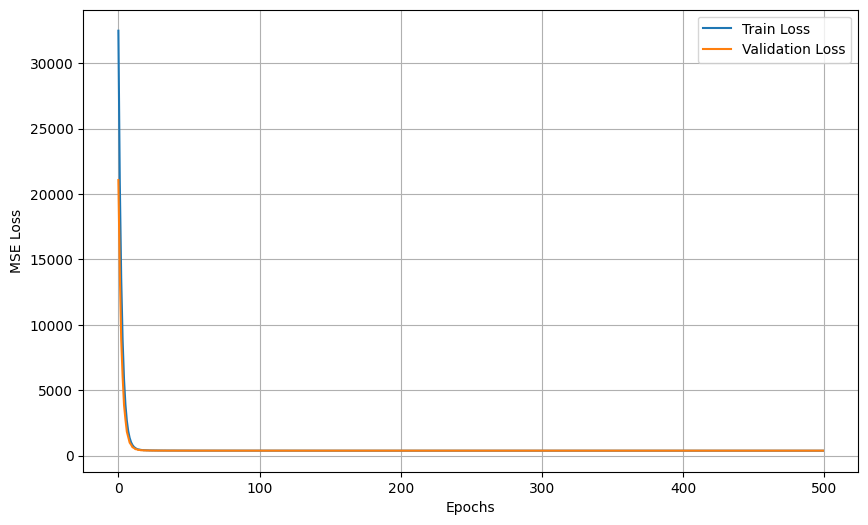

In [6]:
lr = LinearRegressionTorch(X_train.shape[1], lr=0.1)
pipeline(lr, epochs=epochs)

### DNN-16

In [7]:
dnn_16 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[16],
    output_dim=1,
    lr=0.001,
)
dnn_16.model

Sequential(
  (0): Linear(in_features=31, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)

Epoch [50/500], Train Loss: 538.0779, Val Loss: 531.5332
Epoch [100/500], Train Loss: 603.6285, Val Loss: 578.7282
Epoch [150/500], Train Loss: 479.4735, Val Loss: 475.1031
Epoch [200/500], Train Loss: 455.6205, Val Loss: 458.0104
Epoch [250/500], Train Loss: 411.9873, Val Loss: 422.5488
Epoch [300/500], Train Loss: 404.8664, Val Loss: 417.3619
Epoch [350/500], Train Loss: 387.2945, Val Loss: 403.1169
Epoch [400/500], Train Loss: 377.6801, Val Loss: 396.1863
Epoch [450/500], Train Loss: 365.7835, Val Loss: 388.5172
Epoch [500/500], Train Loss: 359.7711, Val Loss: 384.8456

========= Model Evaluation =========
Mean Squared Error (MSE): 398.5806
R^2 Score: 0.4854


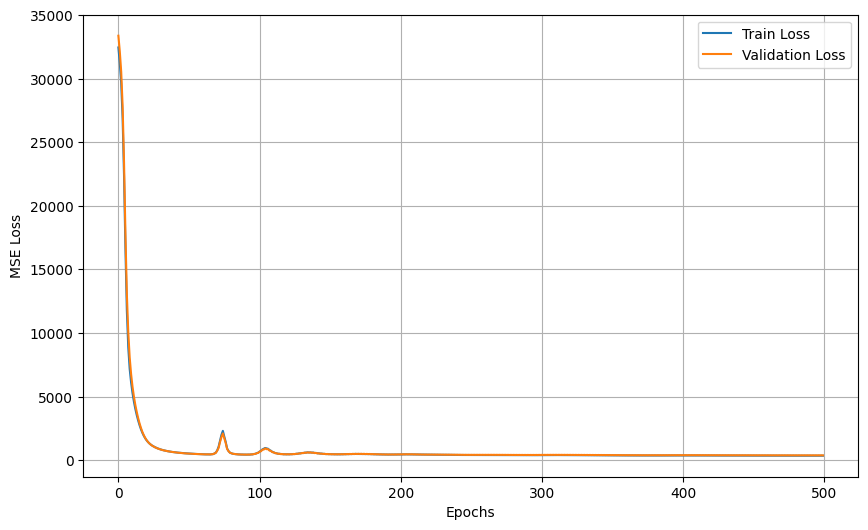

In [8]:
pipeline(dnn_16, epochs=epochs)

## DNN-30-8

In [23]:
dnn_30_8 = DNN(
    input_dim=X_train.shape[1],
    hidden_layers=[30, 16, 8],
    output_dim=1,
    lr=0.0001,
)
dnn_30_8.model

Sequential(
  (0): Linear(in_features=31, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=8, bias=True)
  (5): ReLU()
  (6): Linear(in_features=8, out_features=1, bias=True)
)

Epoch [100/1000], Train Loss: 761.2783, Val Loss: 837.6521
Epoch [200/1000], Train Loss: 598.9230, Val Loss: 662.5108
Epoch [300/1000], Train Loss: 519.1247, Val Loss: 593.2339
Epoch [400/1000], Train Loss: 475.2262, Val Loss: 555.4784
Epoch [500/1000], Train Loss: 439.5433, Val Loss: 522.6016
Epoch [600/1000], Train Loss: 419.9064, Val Loss: 505.7898
Epoch [700/1000], Train Loss: 397.4714, Val Loss: 488.1230
Epoch [800/1000], Train Loss: 359.6050, Val Loss: 455.6133
Epoch [900/1000], Train Loss: 335.8547, Val Loss: 437.4339
Epoch [1000/1000], Train Loss: 307.9034, Val Loss: 433.3697

========= Model Evaluation =========
Mean Squared Error (MSE): 349.6474
R^2 Score: 0.5485


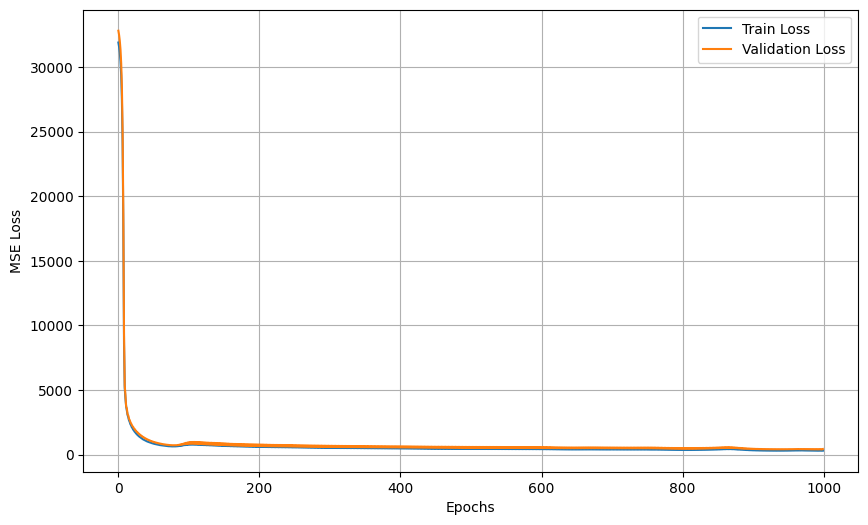

In [24]:
pipeline(dnn_30_8, epochs=1000)